# Nepanglish Code-Switching ASR: Dataset Pilot & Research Blueprint

This notebook provides an end-to-end, CPU-only research pilot exploring the exports from the
**Nepanglish Annotation Harness**.

### Background & Research Goals
- **Domain**: Nepali-English Code-Switching ("Nepanglish") conversational speech recognition.
- **Dataset Structure**: Multi-system cloud ASR hypotheses (`elevenlabs-scribe-v2` phonetic
  transcriber and `gemini-3.8-flash` multimodal LLM), word-level alignments, token-level
  language identification, Code-Mixing Index (CMI), and human verification.
- **Publication Target**: Interspeech / ICASSP / LREC-COLING.
- **Target Scale**: Scaling from this pilot to **5 hours of Gold benchmark data** and **50 hours of
  pseudo-labeled data**.

### The 4 Export Profiles Studied
1. **Training Split (`training.jsonl`)**: Clean `train` and `val` splits for acoustic / seq2seq
   fine-tuning.
2. **Gold Benchmark (`gold.jsonl`)**: Strict `test` split with deterministically rotated seed
   systems (`seed_system_id`) for defensible peer-reviewed benchmarking.
3. **Full Analytics (`analytics.jsonl`)**: Complete diagnostic dataset with multi-system hypotheses,
   word alignments, confidence scores, and cross-ASR disagreement.
4. **Error Mining (`error_mining.jsonl`)**: Filtered negative examples (`uncertain`,
   `unusable_audio`) to isolate failure modes.


## 1. Setup & Environment (CPU-Only)

In [1]:
import json
import re
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Set clean aesthetic styling for plots
style_name = (
    'seaborn-v0_8-whitegrid'
    if 'seaborn-v0_8-whitegrid' in plt.style.available
    else 'default'
)
plt.style.use(style_name)
plt.rcParams.update({'font.size': 11, 'figure.autolayout': True})

print("Environment initialized successfully.")


Environment initialized successfully.


## 2. Ingestion & Manifest Integrity Audit

In [2]:
export_root = Path("../exports") if Path("../exports").is_dir() else Path("exports")

datasets = {}
manifests = {}

for kind in ["training", "gold", "analytics", "error_mining"]:
    data_file = export_root / kind / f"{kind}.jsonl"
    manifest_file = export_root / kind / "manifest.json"

    records = []
    if data_file.is_file():
        with data_file.open(encoding="utf-8") as f:
            for line in f:
                if line.strip():
                    records.append(json.loads(line))
    datasets[kind] = records

    manifest = {}
    if manifest_file.is_file():
        with manifest_file.open(encoding="utf-8") as f:
            manifest = json.load(f)
    manifests[kind] = manifest

audit_summary = []
for kind in ["training", "gold", "analytics", "error_mining"]:
    m = manifests.get(kind, {})
    sha = m.get("files", [{}])[0].get("sha256", "N/A")[:12] if m.get("files") else "N/A"
    audit_summary.append({
        "Export Kind": kind,
        "Rows": len(datasets[kind]),
        "Splits": ", ".join(m.get("filters", {}).get("splits", [])),
        "Dispositions": ", ".join(m.get("filters", {}).get("dispositions", [])),
        "SHA-256 (prefix)": sha,
    })

pd.DataFrame(audit_summary)


,Export Kind,Rows,Splits,Dispositions,SHA-256 (prefix)
0,training,32,"train, val","accepted_unchanged, edited",15ab1797fa3a
1,gold,64,test,"accepted_unchanged, edited",63b72c9375fc
2,analytics,96,"train, val, test, unassigned","accepted_unchanged, edited, uncertain, unusabl...",4e2f31b08df1
3,error_mining,0,"train, val, test, unassigned","uncertain, unusable_audio",e3b0c44298fc


## 3. Linguistic Profiling & Code-Mixing Index (CMI)

The Code-Mixing Index (CMI) quantifies language alternation at the segment level:
$$\text{CMI} = 100 \times \frac{N - \max(N_{\text{ne}}, N_{\text{en}})}{N}$$
where $N = N_{\text{ne}} + N_{\text{en}}$ is the count of non-numeric tokens.


In [3]:
df_analytics = pd.DataFrame(datasets["analytics"])

durations = df_analytics["duration_seconds"].dropna()
cmi_values = df_analytics["code_switch_density"].dropna() * 100.0

total_hours = durations.sum() / 3600.0
print(f"Total Speech Duration: {total_hours:.3f} hours ({len(df_analytics)} segments)")
print(f"Mean Segment Length:   {durations.mean():.2f}s (std = {durations.std():.2f}s)")
print(f"Mean CMI:              {cmi_values.mean():.2f}%")
print(f"Median CMI:            {cmi_values.median():.2f}%")
print(f"Max CMI:               {cmi_values.max():.2f}%")

# Token script breakdown
DEV_RE = re.compile(r"[\u0900-\u097F]")
TOK_RE = re.compile(r"[A-Za-z']+|[\u0900-\u097F]+|\d+")

total_dev, total_lat = 0, 0
for text in df_analytics["text"]:
    tokens = TOK_RE.findall(text or "")
    for t in tokens:
        if not t.isdigit():
            if DEV_RE.search(unicodedata.normalize("NFKC", t)):
                total_dev += 1
            else:
                total_lat += 1

total_tok = total_dev + total_lat
print(f"\nToken Counts:")
print(f"  Devanagari (Nepali): {total_dev} ({total_dev/total_tok*100:.1f}%)")
print(f"  Latin (English):     {total_lat} ({total_lat/total_tok*100:.1f}%)")


Total Speech Duration: 0.358 hours (96 segments)
Mean Segment Length:   13.43s (std = 5.59s)
Mean CMI:              29.38%
Median CMI:            32.52%
Max CMI:               50.00%

Token Counts:
  Devanagari (Nepali): 2438 (64.8%)
  Latin (English):     1325 (35.2%)


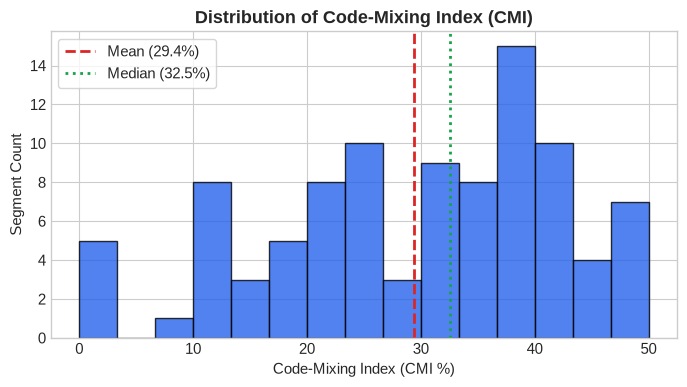

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(cmi_values, bins=15, color="#2563eb", edgecolor="black", alpha=0.8)
ax.set_title("Distribution of Code-Mixing Index (CMI)", fontsize=13, fontweight="bold")
ax.set_xlabel("Code-Mixing Index (CMI %)")
ax.set_ylabel("Segment Count")
mean_lbl = f"Mean ({cmi_values.mean():.1f}%)"
med_lbl = f"Median ({cmi_values.median():.1f}%)"
ax.axvline(cmi_values.mean(), color="#dc2626", linestyle="--", linewidth=2, label=mean_lbl)
ax.axvline(cmi_values.median(), color="#16a34a", linestyle=":", linewidth=2, label=med_lbl)
ax.legend(frameon=True)
plt.show()


## 4. Multi-ASR Benchmark on the Gold Test Split

We implement dynamic programming Levenshtein distance on CPU for both:
1. **Raw Word Error Rate (WER) & Character Error Rate (CER)**.
2. **Normalized WER & CER**: Normalizing Unicode NFKC, stripping punctuation (e.g. Nepali danda `।`,
   commas, quotation marks), and lowercasing Latin words.


In [5]:
PUNCT_CHARS = r'''.,!?;:'"|।॥()[]{}-—'''
PUNCT_RE = re.compile(f"[{re.escape(PUNCT_CHARS)}]")

def normalize_text(text: str | None) -> str:
    if not text:
        return ""
    text = unicodedata.normalize("NFKC", text)
    text = PUNCT_RE.sub(" ", text)
    tokens = text.split()
    normalized = []
    for tok in tokens:
        if not DEV_RE.search(tok):
            normalized.append(tok.lower())
        else:
            normalized.append(tok)
    return " ".join(normalized)

def levenshtein(seq1, seq2):
    m, n = len(seq1), len(seq2)
    if m == 0: return n
    if n == 0: return m
    dp = list(range(n + 1))
    for i in range(1, m + 1):
        prev = dp[0]
        dp[0] = i
        for j in range(1, n + 1):
            temp = dp[j]
            dp[j] = prev if seq1[i - 1] == seq2[j - 1] else 1 + min(prev, dp[j], dp[j - 1])
            prev = temp
    return dp[n]

def compute_wer(ref, hyp):
    r, h = ref.split(), hyp.split()
    return levenshtein(r, h) / len(r) if r else (0.0 if not h else 1.0)

def compute_cer(ref, hyp):
    r, h = list(ref.replace(" ", "")), list(hyp.replace(" ", ""))
    return levenshtein(r, h) / len(r) if r else (0.0 if not h else 1.0)

# Evaluate on Gold test segments
gold_segments = [r for r in datasets["analytics"] if r.get("split") == "test"]

eval_rows = []
for rec in gold_segments:
    ref_raw = rec["text"]
    ref_norm = normalize_text(ref_raw)
    cmi = rec.get("code_switch_density", 0.0) or 0.0
    seed_sys = rec.get("seed_system_id")
    hyps = {h["system_id"]: h["text"] for h in rec.get("hypotheses", [])}

    row = {
        "segment_id": rec["segment_id"],
        "cmi": cmi,
        "seed_system_id": seed_sys,
        "disposition": rec.get("disposition"),
    }
    for sys_name in ["elevenlabs-scribe-v2", "gemini-3.8-flash"]:
        hyp_raw = hyps.get(sys_name, "")
        hyp_norm = normalize_text(hyp_raw)
        row[f"{sys_name}_wer_raw"] = compute_wer(ref_raw, hyp_raw)
        row[f"{sys_name}_wer_norm"] = compute_wer(ref_norm, hyp_norm)
        row[f"{sys_name}_cer_raw"] = compute_cer(ref_raw, hyp_raw)
        row[f"{sys_name}_cer_norm"] = compute_cer(ref_norm, hyp_norm)
    eval_rows.append(row)

df_eval = pd.DataFrame(eval_rows)

bench_summary = []
for sys_name in ["elevenlabs-scribe-v2", "gemini-3.8-flash"]:
    bench_summary.append({
        "System": sys_name,
        "Raw WER (%)": df_eval[f"{sys_name}_wer_raw"].mean() * 100,
        "Normalized WER (%)": df_eval[f"{sys_name}_wer_norm"].mean() * 100,
        "Raw CER (%)": df_eval[f"{sys_name}_cer_raw"].mean() * 100,
        "Normalized CER (%)": df_eval[f"{sys_name}_cer_norm"].mean() * 100,
    })

pd.DataFrame(bench_summary)


,System,Raw WER (%),Normalized WER (%),Raw CER (%),Normalized CER (%)
0,elevenlabs-scribe-v2,22.906771,19.329394,15.536288,14.565625
1,gemini-3.8-flash,31.116656,27.157048,21.361950,20.108277


### Performance by Code-Switching Density Tier

We partition the test split into three CMI bins:
- **Low (< 15% CMI)**: Primarily monolingual Nepali with isolated borrowings.
- **Moderate (15% - 35% CMI)**: Intra-sentential code-switching.
- **High (> 35% CMI)**: Dense code-switching and phrase-level mixing.


,cmi_tier,segments,scribe_norm_wer,gemini_norm_wer,scribe_norm_cer,gemini_norm_cer
0,Low (<15%),12,29.414563,13.505892,24.387161,8.818831
1,Moderate (15-35%),30,19.266187,29.656267,13.293736,23.337847
2,High (>35%),22,13.914583,31.195108,10.942816,21.862198


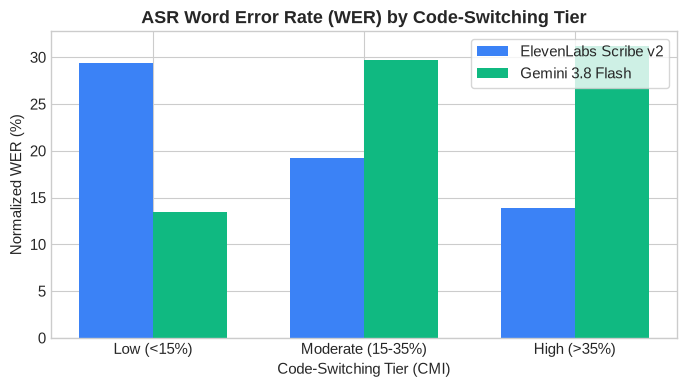

In [6]:
df_eval["cmi_tier"] = pd.cut(
    df_eval["cmi"],
    bins=[-0.01, 0.15, 0.35, 1.0],
    labels=["Low (<15%)", "Moderate (15-35%)", "High (>35%)"],
)

tier_summary = df_eval.groupby("cmi_tier", observed=False).agg(
    segments=("segment_id", "count"),
    scribe_norm_wer=("elevenlabs-scribe-v2_wer_norm", lambda s: s.mean() * 100),
    gemini_norm_wer=("gemini-3.8-flash_wer_norm", lambda s: s.mean() * 100),
    scribe_norm_cer=("elevenlabs-scribe-v2_cer_norm", lambda s: s.mean() * 100),
    gemini_norm_cer=("gemini-3.8-flash_cer_norm", lambda s: s.mean() * 100),
).reset_index()

display(tier_summary)

# Plotting performance by CMI tier
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(tier_summary))
width = 0.35
y1 = tier_summary["scribe_norm_wer"]
y2 = tier_summary["gemini_norm_wer"]
ax.bar(x - width/2, y1, width, label="ElevenLabs Scribe v2", color="#3b82f6")
ax.bar(x + width/2, y2, width, label="Gemini 3.8 Flash", color="#10b981")
ax.set_title("ASR Word Error Rate (WER) by Code-Switching Tier", fontsize=13, fontweight="bold")
ax.set_xlabel("Code-Switching Tier (CMI)")
ax.set_ylabel("Normalized WER (%)")
ax.set_xticks(x)
ax.set_xticklabels(tier_summary["cmi_tier"])
ax.legend(frameon=True)
plt.show()


## 5. Annotator Anchoring & Seed System Bias (Paper Idea 2)

A key architectural feature of this harness is **deterministic seed rotation** on the test split.
Here, we measure how human annotator behavior varies based on which model seeded the UI:


In [7]:
seed_analysis = df_eval.groupby("seed_system_id").agg(
    segments=("segment_id", "count"),
    human_edit_rate=("disposition", lambda d: (d == "edited").mean() * 100),
    wer_against_scribe=("elevenlabs-scribe-v2_wer_norm", lambda s: s.mean() * 100),
    wer_against_gemini=("gemini-3.8-flash_wer_norm", lambda s: s.mean() * 100),
).reset_index()

print("--- Impact of Seed System on Human Annotator Editing & Agreement ---")
display(seed_analysis)


--- Impact of Seed System on Human Annotator Editing & Agreement ---


,seed_system_id,segments,human_edit_rate,wer_against_scribe,wer_against_gemini
0,elevenlabs-scribe-v2,30,3.333333,0.438596,40.851284
1,gemini-3.8-flash,34,20.588235,35.997744,15.073899


## 6. Multi-Teacher Disagreement Gating for Pseudo-Labels (Paper Idea 1)

When scaling to **50 hours of pseudo-labeled audio**, unverified hypotheses will contain errors.
We test the hypothesis that **cross-ASR word disagreement** can serve as an unsupervised gate to
filter out erroneous segments.


Correlation between Cross-ASR Word Disagreement and Human Edits: r = 0.334
Correlation between Cross-ASR Hypothesis CER and Human Edits:    r = 0.357


,Disagreement Threshold (<=),Retained Segments,Retention Rate (%),Noise / Edit Rate in Retained Pool (%)
0,0.2,9,9.375000,11.111111
1,0.4,44,45.833333,6.818182
2,0.6,76,79.166667,5.263158
3,0.8,92,95.833333,9.782609
4,1.0,96,100.000000,12.500000


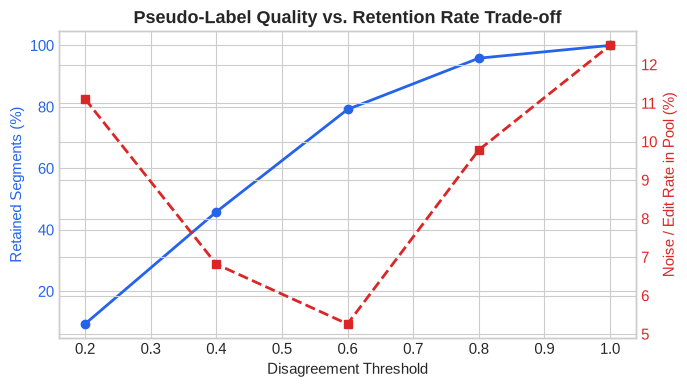

In [8]:
scores_data = []
for r in datasets["analytics"]:
    s = r.get("scores") or {}
    scores_data.append({
        "segment_id": r["segment_id"],
        "is_edited": 1 if r["disposition"] == "edited" else 0,
        "word_disagreement": s.get("word_disagreement_rate", 0.0) or 0.0,
        "cer_disagreement": s.get("cer_between_hypotheses", 0.0) or 0.0,
        "cmi": r.get("code_switch_density", 0.0) or 0.0,
    })

df_scores = pd.DataFrame(scores_data)

corr_w = df_scores["word_disagreement"].corr(df_scores["is_edited"])
corr_c = df_scores["cer_disagreement"].corr(df_scores["is_edited"])
print(f"Correlation between Cross-ASR Word Disagreement and Human Edits: r = {corr_w:.3f}")
print(f"Correlation between Cross-ASR Hypothesis CER and Human Edits:    r = {corr_c:.3f}")

# Threshold filtering simulation
thresholds = [0.2, 0.4, 0.6, 0.8, 1.0]
gating_data = []
for th in thresholds:
    subset = df_scores[df_scores["word_disagreement"] <= th]
    n = len(subset)
    noise_rate = subset["is_edited"].mean() * 100 if n > 0 else 0
    gating_data.append({
        "Disagreement Threshold (<=)": th,
        "Retained Segments": n,
        "Retention Rate (%)": n / len(df_scores) * 100,
        "Noise / Edit Rate in Retained Pool (%)": noise_rate,
    })

df_gating = pd.DataFrame(gating_data)
display(df_gating)

# Plotting the trade-off
fig, ax1 = plt.subplots(figsize=(7, 4))
color1 = "#2563eb"
color2 = "#dc2626"

ax1.set_xlabel("Disagreement Threshold")
ax1.set_ylabel("Retained Segments (%)", color=color1)
x_vals = df_gating["Disagreement Threshold (<=)"]
y_ret = df_gating["Retention Rate (%)"]
y_noise = df_gating["Noise / Edit Rate in Retained Pool (%)"]
ax1.plot(x_vals, y_ret, marker="o", color=color1, linewidth=2, label="Retention %")
ax1.tick_params(axis="y", labelcolor=color1)

ax2 = ax1.twinx()
ax2.set_ylabel("Noise / Edit Rate in Pool (%)", color=color2)
ax2.plot(x_vals, y_noise, marker="s", color=color2, linestyle="--", linewidth=2, label="Noise %")
ax2.tick_params(axis="y", labelcolor=color2)

plt.title("Pseudo-Label Quality vs. Retention Rate Trade-off", fontsize=13, fontweight="bold")
plt.show()


## 7. Paper Draft Ready LaTeX Tables & Summary

Below is the benchmark table formatted in standard LaTeX booktabs for immediate inclusion
into a conference paper draft:


In [9]:
latex_code = pd.DataFrame(bench_summary).to_latex(index=False, float_format="%.2f")
print("% Insert into LaTeX document:")
print(latex_code)


% Insert into LaTeX document:
\begin{tabular}{lrrrr}
\toprule
System & Raw WER (%) & Normalized WER (%) & Raw CER (%) & Normalized CER (%) \\
\midrule
elevenlabs-scribe-v2 & 22.91 & 19.33 & 15.54 & 14.57 \\
gemini-3.8-flash & 31.12 & 27.16 & 21.36 & 20.11 \\
\bottomrule
\end{tabular}

